In [3]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import find_peaks
from functions import *

plt.rcParams.update({'font.size': 12})

AttributeError: module 'matplotlib' has no attribute 'get_data_path'

In [16]:
def sin(t, omega):
    return np.sin(omega*t)

In [29]:
omega1 = 3.
omega2 = 7.
t_end = 50
N = 1000
ts = np.linspace(0, t_end, N)
dt = ts[1] - ts[0]

s1 = sin(ts, omega1)
s2 = sin(ts, omega2)

s = s1 + s2

nuc = 1. / (2. * dt)
nus = np.linspace(0., nuc, round(N/2)) * 2 * np.pi
dnu = nus[1]-nus[0]

omegas = np.linspace(0., np.pi, round(N/2))

poles, adjusted_poles, P_MESE = MESE(omegas, s, 100, 'Reflect')

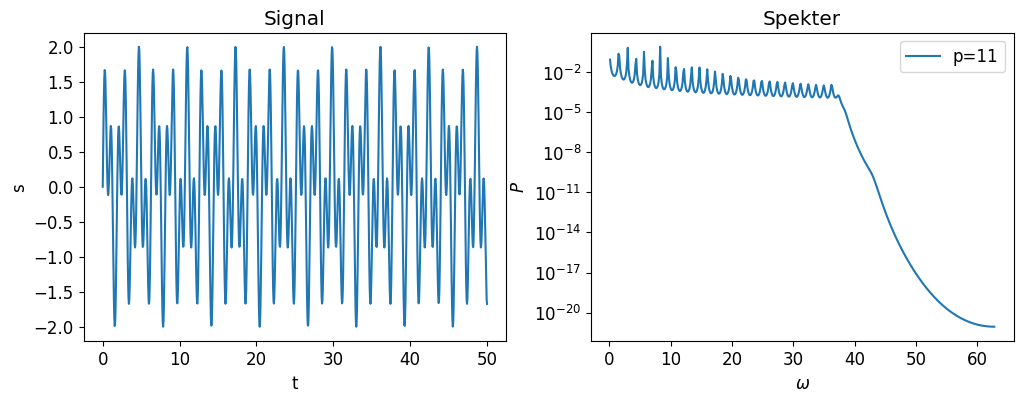

In [30]:
fig = plt.figure(figsize=(12, 4))

ax = fig.add_subplot(1, 2, 1)

ax.plot(ts, s)
ax.set_title('Signal')
ax.set_xlabel('t')
ax.set_ylabel('s')

ax = fig.add_subplot(1, 2, 2)

ax.set_title('Spekter')
ax.set_xlabel(r'$\omega$')
ax.set_ylabel(r'$P$')
ax.set_yscale('log')
ax.plot(nus[1:], P_MESE[1:],  label='p=11')
ax.legend()

In [20]:
omega1 = 3.
omega2s = np.arange(4, 50, 1)

N = 1000
t_end = 50
ts = np.linspace(0, t_end, N)
dt = ts[1] - ts[0]
print(dt)

s1 = sin(ts, omega1)

nuc = 1. / (2. * dt)  # Nyquist frequency
nus = np.linspace(0., nuc, round(N/2)) * 2 * np.pi # Frequency grid for plotting and finding peaks
omegas = np.linspace(0., np.pi, round(N / 2))  # Frequency grid

# Initialize results
minimal_ps = []

# Loop over omega2 values
for omega2 in omega2s:
    # Generate signal
    s2 = sin(ts, omega2)
    s = s1 + s2

    # Find minimal p to resolve peaks
    p = 1  # Start with p=3
    resolved = False
    while not resolved:
        print(f'For {omega2} trying p={p}')
        # Compute spectrum using MESE
        poles, adjusted_poles, P_MESE = MESE(omegas, s, p, 'Reflect')

        # Find peaks in the spectrum
        peaks, _ = find_peaks(P_MESE, height=0.1)  # Adjust height threshold if needed
        peak_omegas = nus[peaks]  # Convert peak indices to frequencies
        print(peak_omegas)

        # Check if peaks are at omega1 and omega2
        if (np.isclose(peak_omegas, omega1, atol=0.1).any() and
                np.isclose(peak_omegas, omega2, atol=0.1).any()):
            resolved = True
        elif p>=100:
            resolved = True
        else:
            p += 1  # Increment p if peaks are not resolved

    minimal_ps.append((omega2 - omega1, p))  # Store minimal p for this omega2

# Results
for omega2, p_min in minimal_ps:
    print(f"Omega2: {omega2:.1f}, Minimal p: {p_min}")


0.05005005005005005
For 4 trying p=1
[]
For 4 trying p=2
[3.52210941]
For 4 trying p=3
[3.52210941]
For 4 trying p=4
[3.52210941]
For 4 trying p=5
[3.52210941]
For 4 trying p=6
[3.64789903]
For 4 trying p=7
[3.64789903]
For 4 trying p=8
[3.64789903]
For 4 trying p=9
[3.64789903]
For 4 trying p=10
[3.64789903]
For 4 trying p=11
[3.64789903]
For 4 trying p=12
[3.64789903]
For 4 trying p=13
[3.64789903]
For 4 trying p=14
[3.52210941]
For 4 trying p=15
[3.52210941]
For 4 trying p=16
[3.52210941]
For 4 trying p=17
[3.39631979]
For 4 trying p=18
[3.27053016 3.89947827]
For 4 trying p=19
[3.14474054 4.02526789]
For 4 trying p=20
[3.14474054 4.02526789]
For 4 trying p=21
[3.01895092 4.02526789]
For 5 trying p=1
[]
For 5 trying p=2
[4.15105752]
For 5 trying p=3
[4.15105752]
For 5 trying p=4
[4.15105752]
For 5 trying p=5
[4.27684714]
For 5 trying p=6
[4.40263676]
For 5 trying p=7
[4.52842638]
For 5 trying p=8
[4.52842638]
For 5 trying p=9
[4.52842638]
For 5 trying p=10
[4.52842638]
For 5 trying 

In [21]:
omega1 = 3.
omega2s = np.arange(4, 50, 1)

N = 1000
t_end = 50
ts = np.linspace(0, t_end, N)
dt = ts[1] - ts[0]
print(dt)

s1 = sin(ts, omega1) + np.random.normal(0.1)

nuc = 1. / (2. * dt)  # Nyquist frequency
nus = np.linspace(0., nuc, round(N/2)) * 2 * np.pi # Frequency grid for plotting and finding peaks
omegas = np.linspace(0., np.pi, round(N / 2))  # Frequency grid

# Initialize results
minimal_ps_noise = []

# Loop over omega2 values
for omega2 in omega2s:
    # Generate signal
    s2 = sin(ts, omega2)
    s = s1 + s2

    # Find minimal p to resolve peaks
    p = 1  # Start with p=1
    resolved = False
    while not resolved:
        print(f'For {omega2} trying p={p}')
        # Compute spectrum using MESE
        poles, adjusted_poles, P_MESE = MESE(omegas, s, p, 'Reflect')

        # Find peaks in the spectrum
        peaks, _ = find_peaks(P_MESE, height=0.1)  # Adjust height threshold if needed
        peak_omegas = nus[peaks]  # Convert peak indices to frequencies
        print(peak_omegas)

        # Check if peaks are at omega1 and omega2
        if (np.isclose(peak_omegas, omega1, atol=0.1).any() and
                np.isclose(peak_omegas, omega2, atol=0.1).any()):
            resolved = True
        elif p>=100:
            resolved = True
        else:
            p += 1  # Increment p if peaks are not resolved

    minimal_ps_noise.append((omega2 - omega1, p))  # Store minimal p for this omega2

# Results
for omega2, p_min in minimal_ps_noise:
    print(f"Omega2: {omega2:.1f}, Minimal p: {p_min}")


0.05005005005005005
For 4 trying p=1
[]
For 4 trying p=2
[3.52210941]
For 4 trying p=3
[3.52210941]
For 4 trying p=4
[3.52210941]
For 4 trying p=5
[3.52210941]
For 4 trying p=6
[3.52210941]
For 4 trying p=7
[3.64789903]
For 4 trying p=8
[3.64789903]
For 4 trying p=9
[3.64789903]
For 4 trying p=10
[3.64789903]
For 4 trying p=11
[3.64789903]
For 4 trying p=12
[3.64789903]
For 4 trying p=13
[3.64789903]
For 4 trying p=14
[3.64789903]
For 4 trying p=15
[3.52210941]
For 4 trying p=16
[3.52210941]
For 4 trying p=17
[3.52210941]
For 4 trying p=18
[3.39631979]
For 4 trying p=19
[3.27053016 3.89947827]
For 4 trying p=20
[3.14474054 4.02526789]
For 4 trying p=21
[3.01895092 4.02526789]
For 5 trying p=1
[]
For 5 trying p=2
[4.15105752]
For 5 trying p=3
[4.15105752]
For 5 trying p=4
[4.15105752]
For 5 trying p=5
[4.27684714]
For 5 trying p=6
[4.40263676]
For 5 trying p=7
[4.52842638]
For 5 trying p=8
[4.52842638]
For 5 trying p=9
[4.52842638]
For 5 trying p=10
[4.52842638]
For 5 trying p=11
[4.528

In [22]:
omega1 = 3.
omega2s = np.arange(4, 50, 1)

N = 1000
t_end = 50
ts = np.linspace(0, t_end, N)
dt = ts[1] - ts[0]
print(dt)

s1 = sin(ts, omega1) + np.random.normal(0.01)

nuc = 1. / (2. * dt)  # Nyquist frequency
nus = np.linspace(0., nuc, round(N/2)) * 2 * np.pi # Frequency grid for plotting and finding peaks
omegas = np.linspace(0., np.pi, round(N / 2))  # Frequency grid

# Initialize results
minimal_ps_noise_01 = []

# Loop over omega2 values
for omega2 in omega2s:
    # Generate signal
    s2 = sin(ts, omega2)
    s = s1 + s2

    # Find minimal p to resolve peaks
    p = 1  # Start with p=1
    resolved = False
    while not resolved:
        print(f'For {omega2} trying p={p}')
        # Compute spectrum using MESE
        poles, adjusted_poles, P_MESE = MESE(omegas, s, p, 'Reflect')

        # Find peaks in the spectrum
        peaks, _ = find_peaks(P_MESE, height=0.1)  # Adjust height threshold if needed
        peak_omegas = nus[peaks]  # Convert peak indices to frequencies
        print(peak_omegas)

        # Check if peaks are at omega1 and omega2
        if (np.isclose(peak_omegas, omega1, atol=0.1).any() and
                np.isclose(peak_omegas, omega2, atol=0.1).any()):
            resolved = True
        elif p>=100:
            resolved = True
        else:
            p += 1  # Increment p if peaks are not resolved

    minimal_ps_noise_01.append((omega2 - omega1, p))  # Store minimal p for this omega2

# Results
for omega2, p_min in minimal_ps_noise_01:
    print(f"Omega2: {omega2:.1f}, Minimal p: {p_min}")


0.05005005005005005
For 4 trying p=1
[]
For 4 trying p=2
[]
For 4 trying p=3
[1.50947546]
For 4 trying p=4
[1.63526508]
For 4 trying p=5
[1.63526508]
For 4 trying p=6
[1.63526508]
For 4 trying p=7
[1.63526508]
For 4 trying p=8
[]
For 4 trying p=9
[2.76737168]
For 4 trying p=10
[3.27053016]
For 4 trying p=11
[3.39631979]
For 4 trying p=12
[3.52210941]
For 4 trying p=13
[3.52210941]
For 4 trying p=14
[3.52210941]
For 4 trying p=15
[3.52210941]
For 4 trying p=16
[3.64789903]
For 4 trying p=17
[ 3.64789903 13.83685838]
For 4 trying p=18
[3.64789903]
For 4 trying p=19
[ 3.64789903 13.71106876]
For 4 trying p=20
[3.64789903]
For 4 trying p=21
[3.64789903]
For 4 trying p=22
[3.64789903]
For 4 trying p=23
[3.64789903]
For 4 trying p=24
[3.64789903]
For 4 trying p=25
[0.25157924 3.64789903]
For 4 trying p=26
[ 0.37736887  3.64789903 11.06948671]
For 4 trying p=27
[ 0.37736887  3.64789903 10.94369709]
For 4 trying p=28
[ 0.37736887  3.64789903 10.94369709]
For 4 trying p=29
[0.25157924 3.6478990

In [23]:
omega1 = 3.
omega2s = np.arange(4, 50, 1)

N = 1000
t_end = 50
ts = np.linspace(0, t_end, N)
dt = ts[1] - ts[0]
print(dt)

s1 = sin(ts, omega1) + np.random.normal(1)

nuc = 1. / (2. * dt)  # Nyquist frequency
nus = np.linspace(0., nuc, round(N/2)) * 2 * np.pi # Frequency grid for plotting and finding peaks
omegas = np.linspace(0., np.pi, round(N / 2))  # Frequency grid

# Initialize results
minimal_ps_noise_1 = []

# Loop over omega2 values
for omega2 in omega2s:
    # Generate signal
    s2 = sin(ts, omega2)
    s = s1 + s2

    # Find minimal p to resolve peaks
    p = 1  # Start with p=1
    resolved = False
    while not resolved:
        print(f'For {omega2} trying p={p}')
        # Compute spectrum using MESE
        poles, adjusted_poles, P_MESE = MESE(omegas, s, p, 'Reflect')

        # Find peaks in the spectrum
        peaks, _ = find_peaks(P_MESE, height=0.1)  # Adjust height threshold if needed
        peak_omegas = nus[peaks]  # Convert peak indices to frequencies
        print(peak_omegas)

        # Check if peaks are at omega1 and omega2
        if (np.isclose(peak_omegas, omega1, atol=0.1).any() and
                np.isclose(peak_omegas, omega2, atol=0.1).any()):
            resolved = True
        elif p>=100:
            resolved = True
        else:
            p += 1  # Increment p if peaks are not resolved

    minimal_ps_noise_1.append((omega2 - omega1, p))  # Store minimal p for this omega2

# Results
for omega2, p_min in minimal_ps_noise_1:
    print(f"Omega2: {omega2:.1f}, Minimal p: {p_min}")


0.05005005005005005
For 4 trying p=1
[]
For 4 trying p=2
[]
For 4 trying p=3
[2.8931613]
For 4 trying p=4
[2.8931613]
For 4 trying p=5
[2.8931613]
For 4 trying p=6
[3.01895092]
For 4 trying p=7
[3.14474054]
For 4 trying p=8
[3.39631979]
For 4 trying p=9
[3.52210941]
For 4 trying p=10
[3.64789903]
For 4 trying p=11
[3.64789903]
For 4 trying p=12
[3.64789903]
For 4 trying p=13
[3.64789903]
For 4 trying p=14
[3.64789903]
For 4 trying p=15
[3.64789903]
For 4 trying p=16
[3.64789903]
For 4 trying p=17
[3.64789903]
For 4 trying p=18
[3.64789903]
For 4 trying p=19
[0.50315849 3.77368865]
For 4 trying p=20
[1.00631697 3.77368865]
For 4 trying p=21
[1.00631697 3.77368865]
For 4 trying p=22
[1.00631697 3.77368865]
For 4 trying p=23
[ 1.00631697  3.77368865 25.28371396]
For 4 trying p=24
[1.00631697 3.77368865]
For 4 trying p=25
[1.00631697 3.77368865]
For 4 trying p=26
[0.37736887 3.77368865]
For 4 trying p=27
[3.77368865]
For 4 trying p=28
[3.77368865]
For 4 trying p=29
[2.8931613  3.89947827]


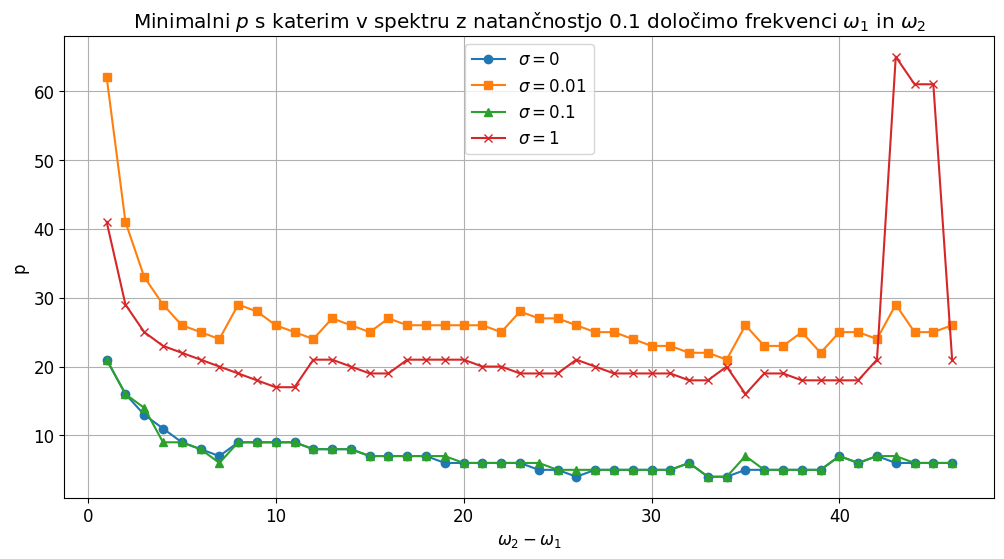

In [24]:
# Optional: Plot minimal p vs. omega2
del_omega_vals, p_vals = zip(*minimal_ps)
del_omega_vals_noise, p_vals_noise = zip(*minimal_ps_noise)
del_omega_vals_noise, p_vals_noise = zip(*minimal_ps_noise)
del_omega_vals_noise_01, p_vals_noise_01 = zip(*minimal_ps_noise_01)
del_omega_vals_noise_1, p_vals_noise_1 = zip(*minimal_ps_noise_1)
plt.figure(figsize=(12, 6))
plt.plot(del_omega_vals, p_vals, marker='o', label=r'$\sigma=0$')
plt.plot(del_omega_vals_noise_01, p_vals_noise_01, marker='s', label=r'$\sigma=0.01$')
plt.plot(del_omega_vals_noise, p_vals_noise, marker='^', label=r'$\sigma=0.1$')
plt.plot(del_omega_vals_noise_1, p_vals_noise_1, marker='x', label=r'$\sigma=1$')
plt.xlabel(r'$\omega_2 - \omega_1$')
plt.ylabel('p')
plt.title(r'Minimalni $p$ s katerim v spektru z natančnostjo 0.1 določimo frekvenci $\omega_1$ in $\omega_2$')
plt.grid()
plt.legend()
plt.show()